In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

print("Path to dataset files:", path)

100%|██████████| 146M/146M [00:00<00:00, 173MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1


In [ ]:
import pandas as pd
import os

# Assuming 'path' variable from the previous cell is accessible or re-derivable
# If not, one would need to re-run the download or define path here
# For robustness, let's explicitly define 'path' again based on common kagglehub output
path = '/root/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1'

# Update path to include the subfolder where the actual data files reside
path = os.path.join(path, 'elliptic_bitcoin_dataset')

# Load the features and classes data
features = pd.read_csv(os.path.join(path, 'elliptic_txs_features.csv'), header=None)
classes = pd.read_csv(os.path.join(path, 'elliptic_txs_classes.csv'))

# Rename first column as txId
features = features.rename(columns={0: "txId"})

# Merge with class labels
data = features.merge(classes, on="txId")

# Remove unknown labels
data = data[data['class'] != 'unknown']

# Convert labels to numeric
data['class'] = data['class'].map({'1': 1, '2': 0})

print(data['class'].value_counts())

class
0    42019
1     4545
Name: count, dtype: int64


In [ ]:
# Load edge list
edges = pd.read_csv(os.path.join(path, 'elliptic_txs_edgelist.csv'))

print("Original edges:", edges.shape)

# Create txId → index mapping
txid_to_index = {tx: i for i, tx in enumerate(data['txId'])}

# Keep only edges where both nodes exist in filtered dataset
edges = edges[
    edges['txId1'].isin(txid_to_index) &
    edges['txId2'].isin(txid_to_index)
]

print("Filtered edges:", edges.shape)

edges.head()

Original edges: (234355, 2)
Filtered edges: (36624, 2)


,txId1,txId2
5,232344069,27553029
8,3881097,232457116
15,232051089,232470704
26,230473487,7089694
33,231182296,14660781


In [ ]:
# Map txIds to numeric indices
edges['source'] = edges['txId1'].map(txid_to_index)
edges['target'] = edges['txId2'].map(txid_to_index)

edges.head()

,txId1,txId2,source,target
5,232344069,27553029,2,3
8,3881097,232457116,4,5
15,232051089,232470704,9,10
26,230473487,7089694,12,13
33,231182296,14660781,19,20


In [ ]:
import torch
from torch_geometric.data import Data

# Node features (drop txId and class)
X = torch.tensor(
    data.drop(['txId', 'class'], axis=1).values,
    dtype=torch.float
)

# Labels
y = torch.tensor(data['class'].values, dtype=torch.long)

# Edge index tensor (shape must be [2, num_edges])
edge_index = torch.tensor(
    edges[['source', 'target']].values.T,
    dtype=torch.long
)

# Create graph data object
graph_data = Data(x=X, edge_index=edge_index, y=y)

print(graph_data)

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Generate indices
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y.numpy(),
    random_state=42
)

# Convert to tensors
train_mask = torch.zeros(len(y), dtype=torch.bool)
test_mask = torch.zeros(len(y), dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

graph_data.train_mask = train_mask
graph_data.test_mask = test_mask

print("Train size:", train_mask.sum().item())
print("Test size:", test_mask.sum().item())

Train size: 37251
Test size: 9313


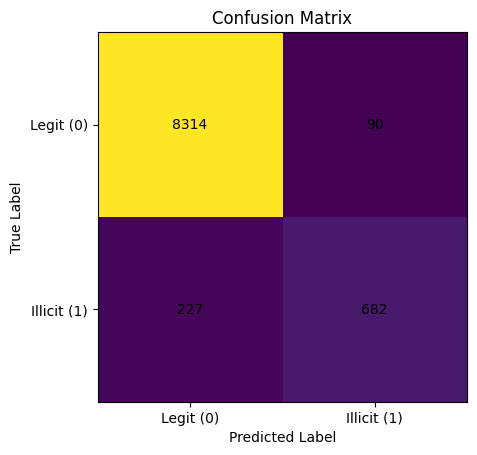

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Ensure model is in evaluation mode
model.eval()

# Get predictions
out = model(graph_data)
pred = out.argmax(dim=1)

# Extract test predictions and true labels
y_true = graph_data.y[graph_data.test_mask].cpu().numpy()
y_pred = pred[graph_data.test_mask].cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Legit (0)", "Illicit (1)"])
plt.yticks([0, 1], ["Legit (0)", "Illicit (1)"])

# Add numbers inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

model = GCN(
    input_dim=X.shape[1],
    hidden_dim=64,
    output_dim=2
)

print(model)

GCN(
  (conv1): GCNConv(166, 64)
  (conv2): GCNConv(64, 2)
)


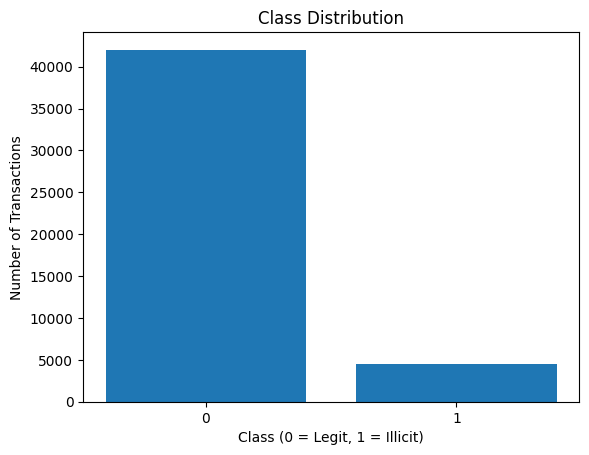

In [ ]:
import matplotlib.pyplot as plt

class_counts = data['class'].value_counts()

plt.figure()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class (0 = Legit, 1 = Illicit)")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")
plt.show()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.NLLLoss()

model.train()

for epoch in range(50):
    optimizer.zero_grad()

    out = model(graph_data)
    loss = criterion(
        out[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6570
Epoch 10, Loss: 0.2158
Epoch 20, Loss: 0.1916
Epoch 30, Loss: 0.1572
Epoch 40, Loss: 0.1448


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

model.eval()
out = model(graph_data)

pred = out.argmax(dim=1)

test_pred = pred[graph_data.test_mask]
test_true = graph_data.y[graph_data.test_mask]

accuracy = accuracy_score(test_true.cpu(), test_pred.cpu())
print("Test Accuracy:", accuracy)

print(classification_report(test_true.cpu(), test_pred.cpu()))

Test Accuracy: 0.9607000966391066
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8404
           1       0.86      0.72      0.78       909

    accuracy                           0.96      9313
   macro avg       0.91      0.85      0.88      9313
weighted avg       0.96      0.96      0.96      9313



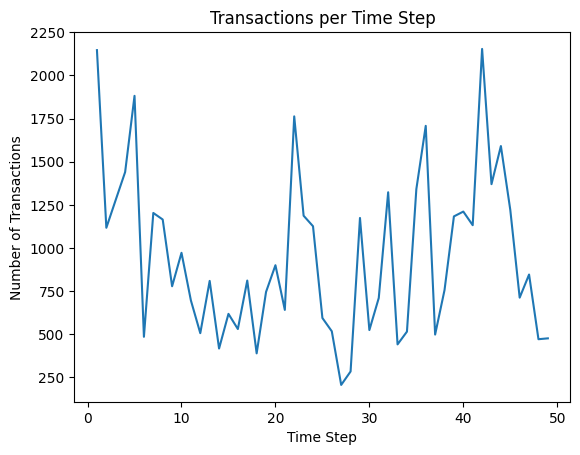

In [ ]:
time_counts = data[1].value_counts().sort_index()

plt.figure()
plt.plot(time_counts.index, time_counts.values)
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.title("Transactions per Time Step")
plt.show()

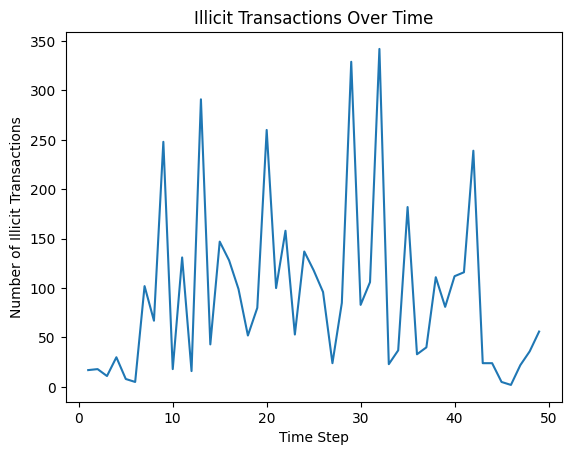

In [ ]:
illicit_data = data[data['class'] == 1]
illicit_time = illicit_data[1].value_counts().sort_index()

plt.figure()
plt.plot(illicit_time.index, illicit_time.values)
plt.xlabel("Time Step")
plt.ylabel("Number of Illicit Transactions")
plt.title("Illicit Transactions Over Time")
plt.show()

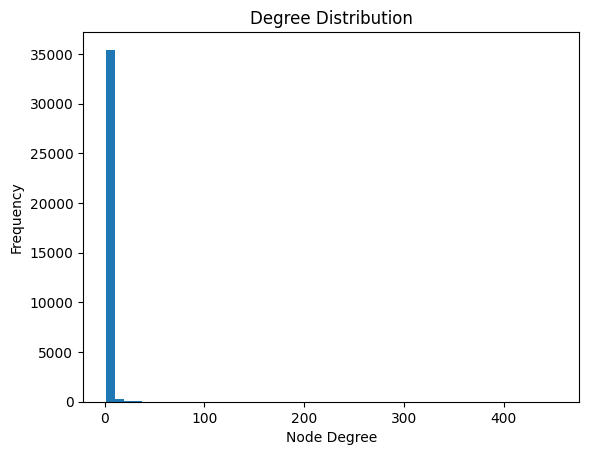

In [ ]:
import networkx as nx

# Create graph
G = nx.from_pandas_edgelist(edges, 'source', 'target')

degrees = [deg for node, deg in G.degree()]

plt.figure()
plt.hist(degrees, bins=50)
plt.xlabel("Node Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")
plt.show()

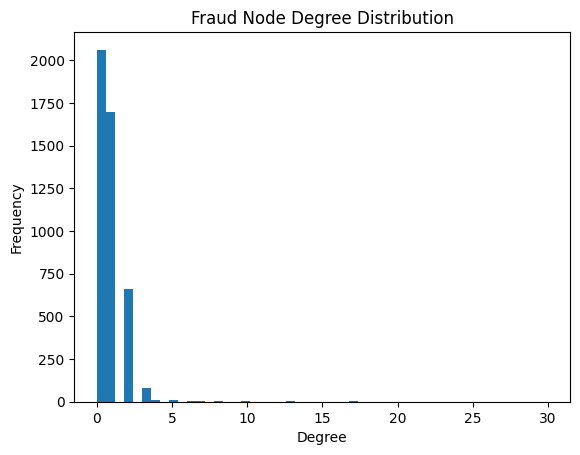

In [ ]:
node_degree = dict(G.degree())

degree_df = data.copy()
degree_df['degree'] = degree_df['txId'].map(
    {tx: node_degree.get(txid_to_index[tx], 0) for tx in txid_to_index}
)

fraud_degree = degree_df[degree_df['class'] == 1]['degree']
legit_degree = degree_df[degree_df['class'] == 0]['degree']

plt.figure()
plt.hist(fraud_degree, bins=50)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Fraud Node Degree Distribution")
plt.show()

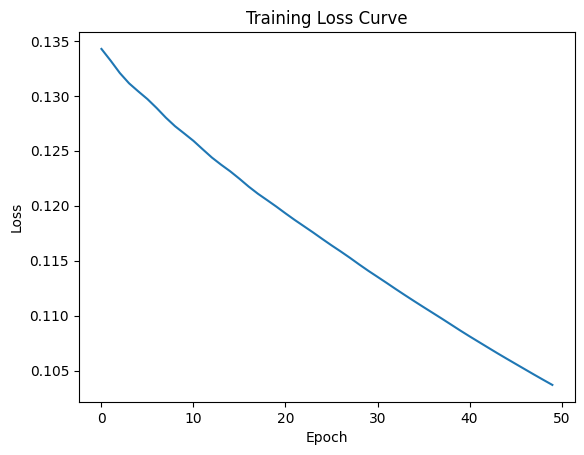

In [ ]:
loss_values = []

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    out = model(graph_data)
    loss = criterion(
        out[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )
    loss.backward()
    optimizer.step()
    loss_values.append(loss.item())

plt.figure()
plt.plot(loss_values)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

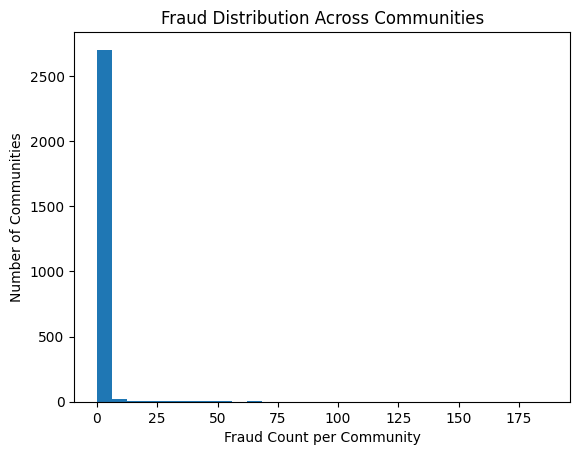

In [ ]:
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt

# Create graph
G = nx.from_pandas_edgelist(edges, 'source', 'target')

# Detect communities
communities = list(community.greedy_modularity_communities(G))

# Assign community labels
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

# Count fraud per community
fraud_counts = []
for i, comm in enumerate(communities):
    fraud_in_comm = sum(
        data.iloc[node]['class'] == 1
        for node in comm if node < len(data)
    )
    fraud_counts.append(fraud_in_comm)

plt.figure()
plt.hist(fraud_counts, bins=30)
plt.xlabel("Fraud Count per Community")
plt.ylabel("Number of Communities")
plt.title("Fraud Distribution Across Communities")
plt.show()

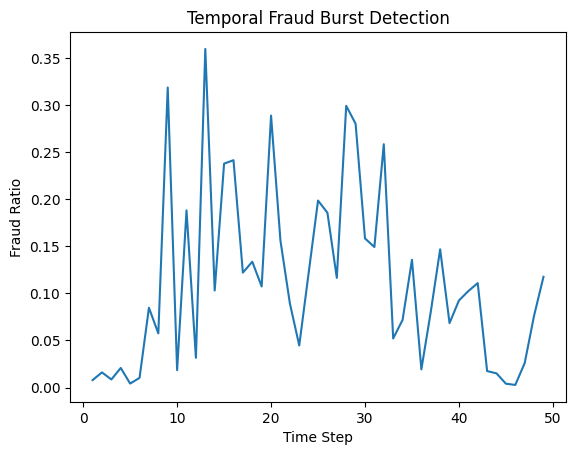

In [ ]:
time_illicit_ratio = (
    data.groupby(1)['class'].mean()
)

plt.figure()
plt.plot(time_illicit_ratio.index, time_illicit_ratio.values)
plt.xlabel("Time Step")
plt.ylabel("Fraud Ratio")
plt.title("Temporal Fraud Burst Detection")
plt.show()

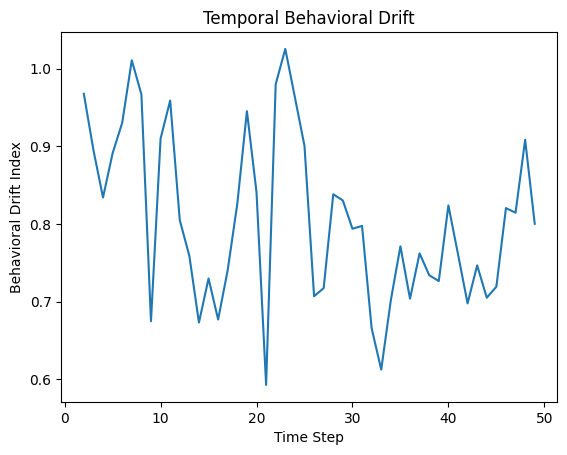

In [ ]:
import numpy as np

time_steps = sorted(data[1].unique())
drift_scores = []

for t in time_steps[1:]:
    current = data[data[1] == t].drop(['txId', 'class'], axis=1).values
    previous = data[data[1] == t-1].drop(['txId', 'class'], axis=1).values

    min_len = min(len(current), len(previous))
    drift = np.mean(np.abs(current[:min_len] - previous[:min_len]))
    drift_scores.append(drift)

plt.figure()
plt.plot(time_steps[1:], drift_scores)
plt.xlabel("Time Step")
plt.ylabel("Behavioral Drift Index")
plt.title("Temporal Behavioral Drift")
plt.show()

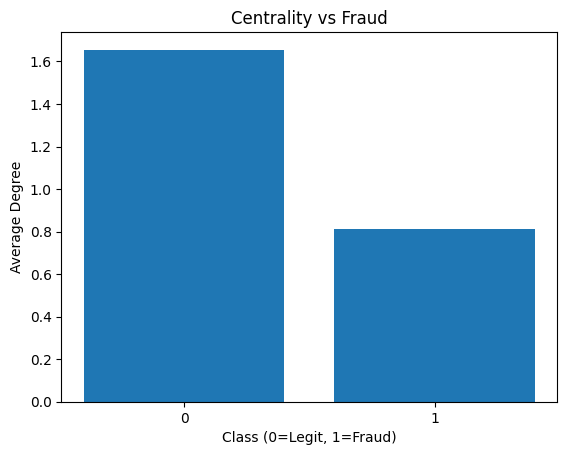

In [ ]:
degree_dict = dict(G.degree())

centrality_df = data.copy()
centrality_df['degree'] = centrality_df['txId'].map(
    {tx: degree_dict.get(txid_to_index[tx], 0) for tx in txid_to_index}
)

fraud_degree_mean = centrality_df.groupby('class')['degree'].mean()

plt.figure()
plt.bar(fraud_degree_mean.index.astype(str), fraud_degree_mean.values)
plt.xlabel("Class (0=Legit, 1=Fraud)")
plt.ylabel("Average Degree")
plt.title("Centrality vs Fraud")
plt.show()

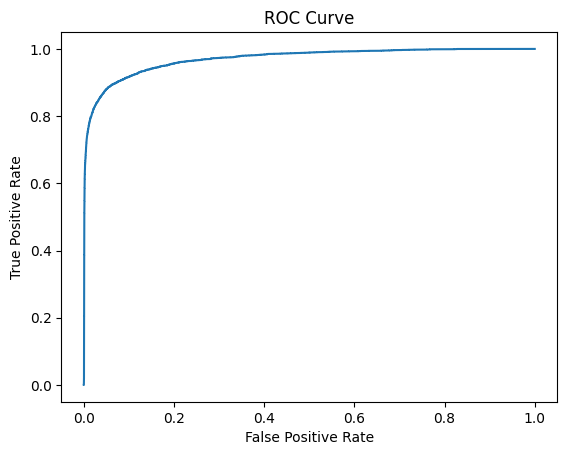

In [ ]:
from sklearn.metrics import roc_curve
import torch

model.eval()
out = model(graph_data)
prob = torch.exp(out)[:,1].detach().cpu().numpy()
true = graph_data.y.cpu().numpy()

fpr, tpr, _ = roc_curve(true, prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()